<a href="https://colab.research.google.com/github/imsumedhaa/fireducks-vs-pandas-EDA/blob/main/EDA_%26_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install fireducks

# Enable benchmark mode
from fireducks.core import get_fireducks_options
get_fireducks_options().set_benchmark_mode(True)

import pandas as pd
import fireducks.pandas as fd
import numpy as np
import time
import matplotlib.pyplot as plt

# Create dummy sales dataset
df = pd.DataFrame({
    "product": np.random.choice(["apple", "banana", "orange", "kiwi"], size=1_000_000),
    "region": np.random.choice(["north", "south", "east", "west"], size=1_000_000),
    "price": np.random.uniform(10, 200, size=1_000_000),
    "units_sold": np.random.randint(1, 100, size=1_000_000)
})
df.to_csv("sales_data.csv", index=False)
print("✅ Created 'sales_data.csv'")

# Load CSV
start = time.time()
pandas_df = pd.read_csv("sales_data.csv")
print("📄 Pandas Read Time:", round(time.time() - start, 4), "sec")

start = time.time()
fd_df = fd.read_csv("sales_data.csv")
print("🔥 FireDucks Read Time:", round(time.time() - start, 4), "sec")




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 MB 17.9 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
✅ Created 'sales_data.csv'
📄 Pandas Read Time: 0.4986 sec
🔥 FireDucks Read Time: 0.2825 sec


In [4]:
# Force FireDucks evaluation
def evaluate(df):
    try:
        df._evaluate()
    except AttributeError:
        pass
# Filter rows with price > 100
start = time.time()
filtered_pandas = pandas_df[pandas_df['price'] > 100]
print("📉 Pandas Filter Time:", round(time.time() - start, 4), "sec")

start = time.time()
filtered_fd = fd_df[fd_df['price'] > 100]

# ✅ FireDucks-specific logic: simulate promo in 'north' region using np.where
filtered_fd['units_sold'] = np.where(
    filtered_fd['region'] == 'north',
    filtered_fd['units_sold'] * 2,
    filtered_fd['units_sold']
)
evaluate(filtered_fd)
print("🔥 FireDucks Filter + Promo Logic Time:", round(time.time() - start, 4), "sec")

📉 Pandas Filter Time: 0.0788 sec
🔥 FireDucks Filter + Promo Logic Time: 0.2066 sec


In [5]:
# Group by region and average units_sold
start = time.time()
group_pandas = filtered_pandas.groupby('region')['units_sold'].mean().reset_index()
print("📊 Pandas GroupBy Time:", round(time.time() - start, 4), "sec")

start = time.time()
group_fd = filtered_fd.groupby('region')['units_sold'].mean().reset_index()
evaluate(group_fd)
print("🔥 FireDucks GroupBy Time:", round(time.time() - start, 4), "sec")


📊 Pandas GroupBy Time: 0.0479 sec
🔥 FireDucks GroupBy Time: 0.0182 sec


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


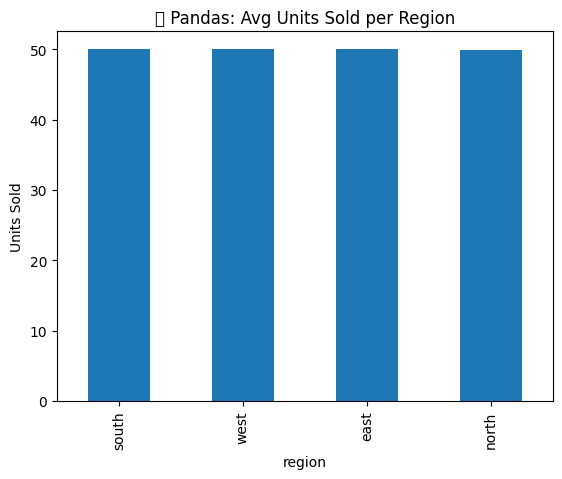

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


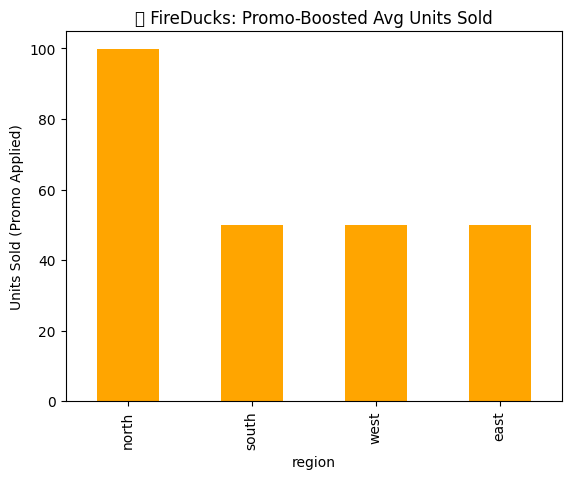

✅ Benchmark + Visualization Complete!


In [6]:
# Sort by units_sold descending
sorted_pandas = group_pandas.sort_values(by='units_sold', ascending=False)
sorted_fd = group_fd.sort_values(by='units_sold', ascending=False)

# Plot results
sorted_pandas.plot(kind='bar', x='region', y='units_sold', title="📊 Pandas: Avg Units Sold per Region", legend=False)
plt.ylabel("Units Sold")
plt.show()

sorted_fd.plot(kind='bar', x='region', y='units_sold', title="🔥 FireDucks: Promo-Boosted Avg Units Sold", color='orange', legend=False)
plt.ylabel("Units Sold (Promo Applied)")
plt.show()

print("✅ Benchmark + Visualization Complete!")